# Day 1 — Cost Function (MSE)

the goal today is to understand how we know if our line is good or bad  
we do that by measuring the error between what we predicted and what's real

formula: `f(x) = wx + b`

In [1]:
import matplotlib.pyplot as plt

In [2]:
# house size (sqft) → price (thousands)
x_train = [1100, 1400, 1700]
y_train = [250,  300,  350]

bias = 67  # b in f(x) = wx + b

# testing a few weights to see which one fits best
w = [0.155, 0.166, 0.200, 0.300]

In [3]:
def compt_cost(x, y, b, w):
    result = {}
    m = len(x)

    for i in range(len(w)):
        total = 0
        for j in range(m):
            prediction = w[i] * x[j] + b
            error = (prediction - y[j]) ** 2  # squared so negatives don't cancel out
            total += error

        cost = (1 / (2 * m)) * total  # divide by 2m (standard MSE formula)
        result[w[i]] = cost

    best_w = min(result, key=result.get)  # pick the w with the lowest cost
    return result, f"best w={best_w} → cost={result[best_w]:.4f}"


costs, best = compt_cost(x_train, y_train, bias, w)
print(costs)
print(best)

{0.155: 132.08333333333331, 0.166: 0.19333333333333785, 0.2: 1137.8333333333333, 0.3: 18017.833333333332}
best w=0.166 → cost=0.1933


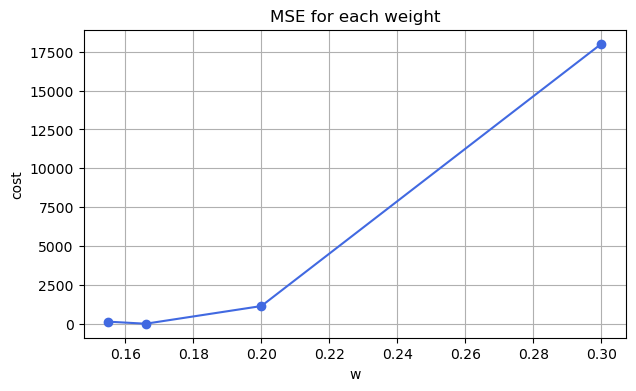

In [8]:
costs, best = compt_cost(x_train, y_train, bias, w)

# pull keys and values out of the dict
weights_list = list(costs.keys())
mse_list = list(costs.values())

plt.figure(figsize=(7, 4))
plt.plot(weights_list, mse_list, color='royalblue', marker='o')
plt.title('MSE for each weight')
plt.xlabel('w')
plt.ylabel('cost')
plt.grid(True)
plt.show()

## what i got from today

- the cost function tells us how wrong our model is
- we square the errors so positive and negative mistakes don't cancel out
- lower cost = better weight
- right now we're testing weights manually — tomorrow gradient descent does this automatically